Download do dataset Fake.Br Corpus

In [ ]:
import os
import requests
import zipfile
import pandas as pd

# 1. Download do Dataset Fake.Br Corpus do GitHub oficial
print("Baixando o dataset Fake.Br Corpus... aguarde.")
url = "https://github.com/roneysco/Fake.br-Corpus/archive/refs/heads/master.zip"
r = requests.get(url )
with open("dataset.zip", "wb") as f:
    f.write(r.content)

# 2. Extraindo os arquivos
print("Extraindo arquivos...")
with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("fake_br")

# 3. Organizando as notícias em uma tabela
print("Organizando os dados...")
base_path = "fake_br/Fake.br-Corpus-master/full_texts"
fake_path = os.path.join(base_path, "fake")
true_path = os.path.join(base_path, "true")

data = []

# Carregar notícias falsas
for filename in os.listdir(fake_path):
    if filename.endswith(".txt"):
        with open(os.path.join(fake_path, filename), "r", encoding="utf-8") as f:
            data.append({"text": f.read(), "label": 1})

# Carregar notícias verdadeiras
for filename in os.listdir(true_path):
    if filename.endswith(".txt"):
        with open(os.path.join(true_path, filename), "r", encoding="utf-8") as f:
            data.append({"text": f.read(), "label": 0})

# Criar a tabela final
df = pd.DataFrame(data)
print(f"\nSucesso! Dataset carregado com {len(df)} notícias.")
print("Exemplo das primeiras linhas:")
print(df.head())


Baixando o dataset Fake.Br Corpus... aguarde.
Extraindo arquivos...
Organizando os dados...

Sucesso! Dataset carregado com 7200 notícias.
Exemplo das primeiras linhas:
                                                text  label
0  Líder do PT, Gleise Homann promete "detonar" S...      1
1  Moro rebate argumentos dos advogados de Lula: ...      1
2  Defesa horrenda! Dilma conseguiu reverter algu...      1
3  A casa caiu [ops ...] A cueca caiu! PGR denunc...      1
4  Rodrigo Maia disse que vai arquivar pedidos de...      1


 Instalação das Bibliotecas de IA e Tokenização.

In [ ]:
# 1. Instalação das bibliotecas da Hugging Face e PyTorch
print("Instalando bibliotecas de IA... aguarde um momento.")
!pip install transformers[torch] datasets scikit-learn -q

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import Dataset
from sklearn.model_selection import train_test_split

# 2. Carregando o Tokenizer do BERTimbau
print("Carregando o Tokenizer do BERTimbau (neuralmind/bert-base-portuguese-cased)...")
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = BertTokenizer.from_pretrained(model_name)

# 3. Função para transformar texto em números (Tokens)
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

# 4. Dividindo os dados em Treino (80%) e Teste (20%)
print("Dividindo os dados para o experimento...")

# Check if 'df' is defined. If not, raise an informative error.
if 'df' not in locals() and 'df' not in globals():
    raise NameError("Variável 'df' não encontrada. Por favor, certifique-se de que a célula que carrega o dataset 'df' (a célula anterior) foi executada.")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Converter para o formato que a biblioteca Hugging Face utiliza
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Aplicar a tokenização nos dados
print("Tokenizando os textos (transformando em números)... isso pode levar 1 ou 2 minutos.")
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("\nSucesso! Bibliotecas instaladas e dados preparados para o treinamento.")

Instalando bibliotecas de IA... aguarde um momento.
Carregando o Tokenizer do BERTimbau (neuralmind/bert-base-portuguese-cased)...


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Dividindo os dados para o experimento...
Tokenizando os textos (transformando em números)... isso pode levar 1 ou 2 minutos.


Map:   0%|          | 0/5760 [00:00<?, ? examples/s]

Map:   0%|          | 0/1440 [00:00<?, ? examples/s]


Sucesso! Bibliotecas instaladas e dados preparados para o treinamento.


 Fine-Tuning e Avaliação.

Carregando o modelo BERTimbau...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th


>>> Iniciando o treinamento. Isso vai levar uns 15-20 minutos.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.008531,0.081017,0.979167,0.979480,0.962366,0.997214
2,0.000505,0.046542,0.993750,0.993702,0.998594,0.988858
3,0.002237,0.030334,0.993750,0.993737,0.993046,0.994429


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


>>> Treinamento concluído! Calculando métricas finais...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.002237,0.030334,3,0.993750,0.993737,0.993046,0.994429



--- RESULTADOS FINAIS ---
eval_loss: 0.0303
eval_accuracy: 0.9938
eval_f1: 0.9937
eval_precision: 0.9930
eval_recall: 0.9944


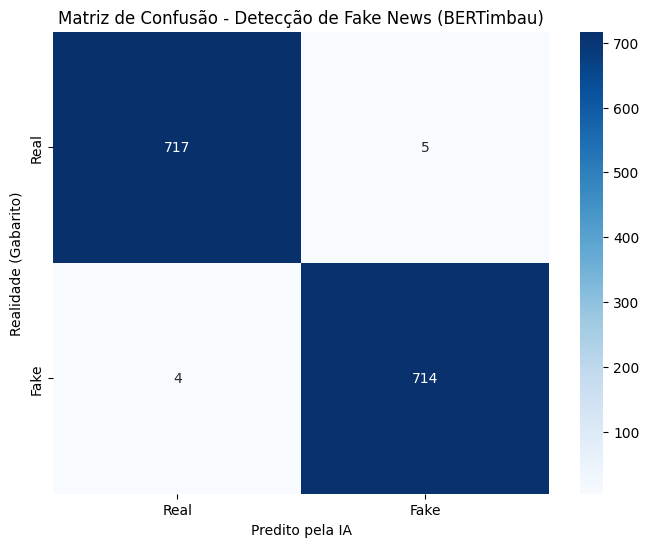

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregando o modelo BERTimbau para Classificação
print("Carregando o modelo BERTimbau...")
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 2. Configurações do Treinamento (Hiperparâmetros)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# 3. Função para calcular as métricas de sucesso
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 4. Inicializando o Treinador (Trainer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 5. INICIANDO O TREINAMENTO (O Fine-Tuning)
print("\n>>> Iniciando o treinamento. Isso vai levar uns 15-20 minutos.")
trainer.train()

# 6. AVALIAÇÃO FINAL
print("\n>>> Treinamento concluído! Calculando métricas finais...")
results = trainer.evaluate()

print("\n--- RESULTADOS FINAIS ---")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

# 7. GERANDO A MATRIZ DE CONFUSÃO
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(-1)
y_true = test_df['label'].values

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predito pela IA')
plt.ylabel('Realidade (Gabarito)')
plt.title('Matriz de Confusão - Detecção de Fake News (BERTimbau)')
plt.show()


Gráfico de Barras e Gráfico de Desempenho por Categoria

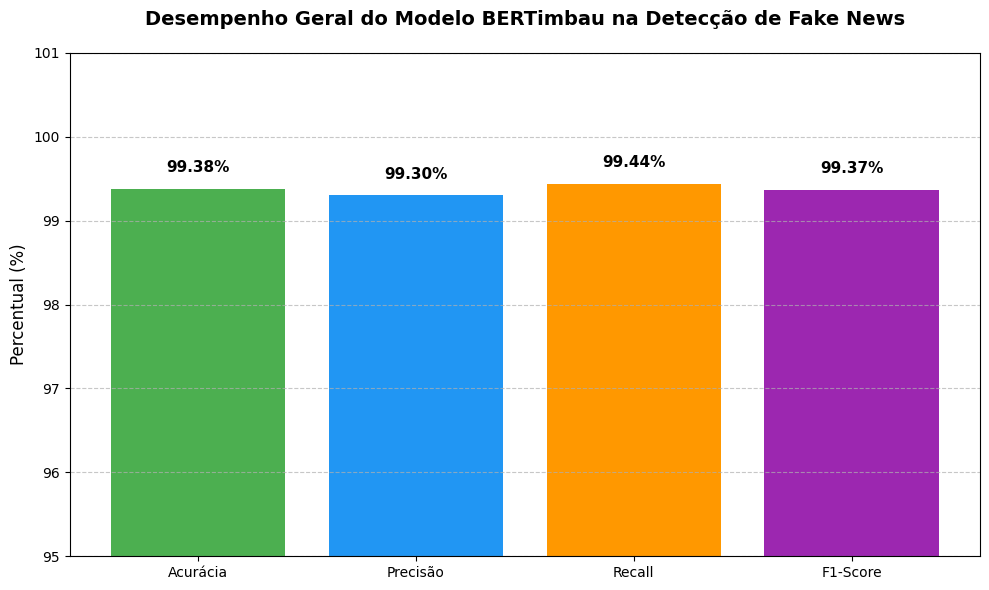

In [ ]:
import matplotlib.pyplot as plt

# Dados reais obtidos no seu experimento
metricas = {
    'Acurácia': 99.38,
    'Precisão': 99.30,
    'Recall': 99.44,
    'F1-Score': 99.37
}

# Configuração do Gráfico de Barras
plt.figure(figsize=(10, 6))
cores = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

# Criando as barras
barras = plt.bar(metricas.keys(), metricas.values(), color=cores)

# Ajustando o limite lateral para destacar a alta performance
plt.ylim(95, 101)

# Adicionando títulos e rótulos
plt.ylabel('Percentual (%)', fontsize=12)
plt.title('Desempenho Geral do Modelo BERTimbau na Detecção de Fake News', fontsize=14, fontweight='bold', pad=20)

# Adicionando os valores exatos em cima de cada barra
for i, v in enumerate(metricas.values()):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

# Adicionando grade para facilitar a leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.tight_layout()
plt.show()

